In [ ]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 


df = pd.read_csv('seasonal_agriculture_performance_dataset.csv')

df.head()

In [3]:
print("Number of Rows:", df.shape[0])
print("Number of Columns:", df.shape[1])

Number of Rows: 4000
Number of Columns: 28


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 28 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Farm_ID                        4000 non-null   str    
 1   State                          4000 non-null   str    
 2   District                       4000 non-null   str    
 3   Crop                           4000 non-null   str    
 4   Season                         4000 non-null   str    
 5   Farm_Area_Hectares             4000 non-null   float64
 6   Rainfall_mm                    3952 non-null   float64
 7   Avg_Temperature_C              4000 non-null   float64
 8   Humidity_pct                   4000 non-null   float64
 9   Sunlight_Hours_Day             4000 non-null   float64
 10  Soil_pH                        4000 non-null   float64
 11  Soil_Moisture_pct              3960 non-null   float64
 12  Nitrogen_kg_ha                 4000 non-null   float64
 13 

In [5]:
df.isnull().sum()

Farm_ID                           0
State                             0
District                          0
Crop                              0
Season                            0
Farm_Area_Hectares                0
Rainfall_mm                      48
Avg_Temperature_C                 0
Humidity_pct                      0
Sunlight_Hours_Day                0
Soil_pH                           0
Soil_Moisture_pct                40
Nitrogen_kg_ha                    0
Phosphorus_kg_ha                  0
Potassium_kg_ha                   0
Irrigation_Method                 0
Fertilizer_kg_ha                  0
Pesticide_Litre_ha                0
Seed_Quality_Score                0
Yield_Tonnes_Ha                  32
Production_Tonnes                 0
Market_Price_INR_Tonne            0
Total_Cost_INR                    0
Revenue_INR                       0
Profit_INR                        0
Water_Used_m3                     0
Water_Efficiency_t_per_1000m3     0
Disease_Pest_Risk_pct       

In [6]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


In [7]:
df.describe()

,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
count,4000.000000,3952.000000,4000.00000,4000.000000,4000.000000,4000.000000,3960.000000,4000.000000,4000.000000,4000.000000,...,4000.000000,3968.000000,4000.000000,4000.000000,4.000000e+03,4.000000e+03,4.000000e+03,4000.000000,4000.000000,4000.000000
mean,7.888265,601.152657,26.81890,63.210500,7.323050,6.701010,26.508232,120.250825,57.781850,104.760050,...,0.826138,5.270595,43.246210,44714.166250,5.263036e+05,6.378600e+05,1.115565e+05,6045.570250,5.385214,46.365875
std,4.223764,288.925025,3.81818,11.960834,1.121186,0.641461,6.712484,31.216452,17.015074,27.742681,...,0.101747,13.361398,126.880521,30266.161922,2.944191e+05,6.369747e+05,5.450819e+05,5572.944306,8.838101,12.424417
min,0.500000,80.000000,16.20000,25.000000,3.500000,5.200000,8.000000,40.000000,15.000000,30.000000,...,0.650000,0.300000,0.150000,2594.000000,2.682600e+04,6.107000e+03,-1.019223e+06,128.000000,0.135000,5.000000
25%,4.260000,370.200000,23.90000,54.775000,6.600000,6.260000,21.700000,98.500000,46.200000,86.200000,...,0.740000,1.050000,5.020000,21429.250000,2.745775e+05,2.075172e+05,-1.487318e+05,2268.750000,1.661000,37.300000
50%,7.895000,582.000000,26.90000,63.000000,7.300000,6.690000,26.400000,120.100000,57.500000,105.100000,...,0.830000,1.740000,11.770000,25913.000000,5.190825e+05,4.568305e+05,3.673000e+03,4435.000000,2.937500,46.400000
75%,11.650000,834.950000,29.60000,71.900000,8.100000,7.140000,31.300000,141.225000,69.400000,123.600000,...,0.910000,2.840000,24.355000,68279.000000,7.619965e+05,8.368748e+05,2.161878e+05,7829.750000,5.150250,54.900000
max,15.000000,1395.200000,39.70000,95.000000,11.000000,8.400000,47.000000,220.000000,120.000000,200.000000,...,1.000000,101.440000,1424.400000,131240.000000,1.349990e+06,5.080900e+06,4.345421e+06,40902.000000,79.800000,88.900000


In [8]:
df["Season"].value_counts()

Season
Kharif    1779
Rabi      1627
Zaid       594
Name: count, dtype: int64

In [9]:
season_summary = df.groupby("Season")[[
    "Yield_Tonnes_Ha",
    "Production_Tonnes",
    "Revenue_INR",
    "Profit_INR",
    "Water_Used_m3",
    "Water_Efficiency_t_per_1000m3"
]].mean()

season_summary

,Yield_Tonnes_Ha,Production_Tonnes,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3
Season,,,,,,
Kharif,5.643973,46.311192,710719.055649,178914.647555,6102.201237,5.891834
Rabi,5.080498,41.486712,601526.048556,87689.470191,5846.987093,5.186122
Zaid,4.665942,38.886111,519171.904040,-24804.824916,6419.893939,4.413239


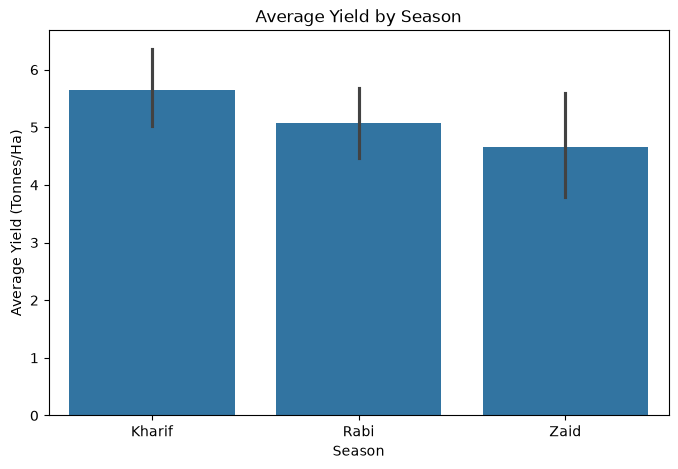

In [10]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=df,
    x="Season",
    y="Yield_Tonnes_Ha",
    estimator="mean"
)

plt.title("Average Yield by Season")
plt.xlabel("Season")
plt.ylabel("Average Yield (Tonnes/Ha)")
plt.show()

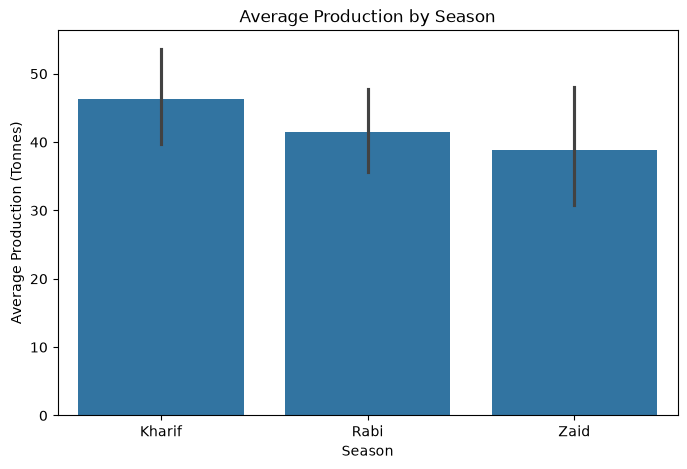

In [11]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=df,
    x="Season",
    y="Production_Tonnes",
    estimator="mean"
)

plt.title("Average Production by Season")
plt.xlabel("Season")
plt.ylabel("Average Production (Tonnes)")
plt.show()

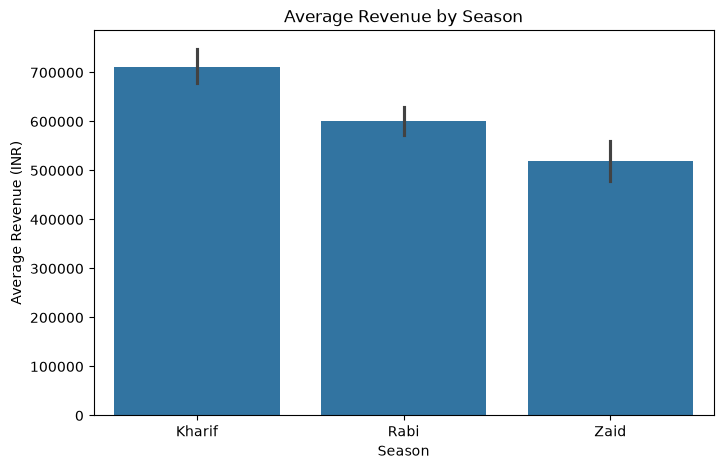

In [12]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=df,
    x="Season",
    y="Revenue_INR",
    estimator="mean"
)

plt.title("Average Revenue by Season")
plt.xlabel("Season")
plt.ylabel("Average Revenue (INR)")
plt.show()

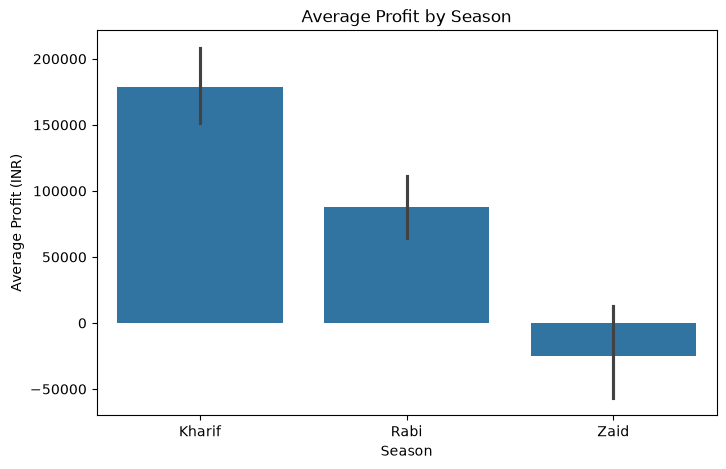

In [13]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=df,
    x="Season",
    y="Profit_INR",
    estimator="mean"
)

plt.title("Average Profit by Season")
plt.xlabel("Season")
plt.ylabel("Average Profit (INR)")
plt.show()

In [14]:
crop_yield = df.groupby("Crop")["Yield_Tonnes_Ha"].mean().sort_values(ascending=False)

crop_yield

Crop
Sugarcane    46.938746
Maize         2.717130
Rice          2.439413
Wheat         2.109216
Chilli        1.540344
Groundnut     1.317924
Cotton        1.225734
Pulses        0.918198
Name: Yield_Tonnes_Ha, dtype: float64

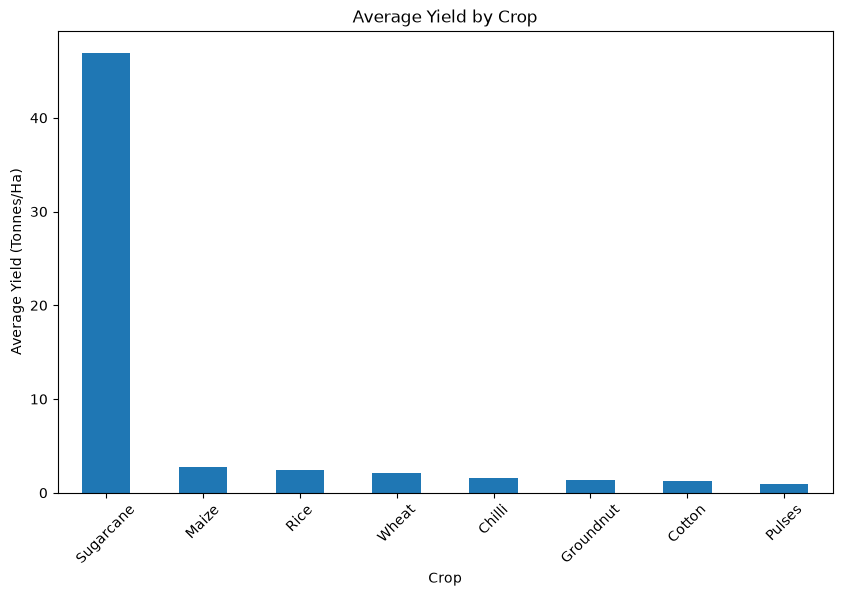

In [15]:
plt.figure(figsize=(10,6))

crop_yield.plot(kind="bar")

plt.title("Average Yield by Crop")
plt.xlabel("Crop")
plt.ylabel("Average Yield (Tonnes/Ha)")
plt.xticks(rotation=45)
plt.show()


In [16]:
season_crop = df.pivot_table(
    values="Yield_Tonnes_Ha",
    index="Crop",
    columns="Season",
    aggfunc="mean"
)

season_crop

Season,Kharif,Rabi,Zaid
Crop,,,
Chilli,1.731413,1.461615,1.177742
Cotton,1.372804,1.192915,0.951648
Groundnut,1.483646,1.221445,1.037778
Maize,2.966410,2.614913,2.297590
Pulses,1.036063,0.871887,0.652131
Rice,2.707621,2.333680,1.900490
Sugarcane,53.459120,43.940394,38.423922
Wheat,2.255430,2.058814,1.748588


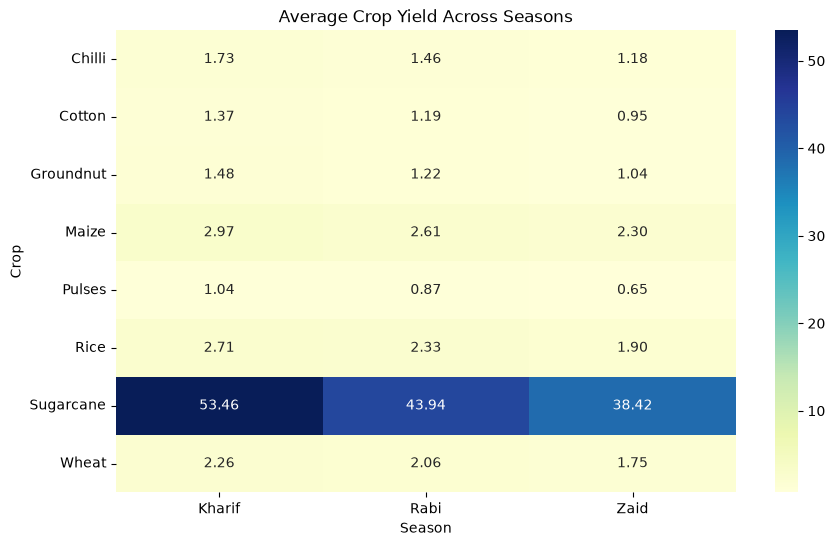

In [17]:
plt.figure(figsize=(10,6))

sns.heatmap(
    season_crop,
    annot=True,
    fmt=".2f",
    cmap="YlGnBu"
)

plt.title("Average Crop Yield Across Seasons")
plt.xlabel("Season")
plt.ylabel("Crop")
plt.show()

In [18]:
numeric_columns = [
    "Rainfall_mm",
    "Avg_Temperature_C",
    "Humidity_pct",
    "Sunlight_Hours_Day",
    "Soil_pH",
    "Soil_Moisture_pct",
    "Nitrogen_kg_ha",
    "Phosphorus_kg_ha",
    "Potassium_kg_ha",
    "Fertilizer_kg_ha",
    "Pesticide_Litre_ha",
    "Seed_Quality_Score",
    "Yield_Tonnes_Ha",
    "Production_Tonnes",
    "Market_Price_INR_Tonne",
    "Total_Cost_INR",
    "Revenue_INR",
    "Profit_INR",
    "Water_Used_m3",
    "Water_Efficiency_t_per_1000m3",
    "Disease_Pest_Risk_pct"
]

correlation = df[numeric_columns].corr()

correlation["Yield_Tonnes_Ha"].sort_values(ascending=False)

Yield_Tonnes_Ha                  1.000000
Water_Efficiency_t_per_1000m3    0.915438
Production_Tonnes                0.885171
Profit_INR                       0.489822
Revenue_INR                      0.433648
Water_Used_m3                    0.388653
Nitrogen_kg_ha                   0.053867
Phosphorus_kg_ha                 0.047821
Rainfall_mm                      0.030853
Total_Cost_INR                   0.030814
Disease_Pest_Risk_pct            0.013490
Humidity_pct                     0.011277
Soil_Moisture_pct                0.010210
Avg_Temperature_C                0.009349
Potassium_kg_ha                  0.003836
Fertilizer_kg_ha                 0.000562
Seed_Quality_Score              -0.006737
Pesticide_Litre_ha              -0.007650
Sunlight_Hours_Day              -0.015362
Soil_pH                         -0.020664
Market_Price_INR_Tonne          -0.384307
Name: Yield_Tonnes_Ha, dtype: float64

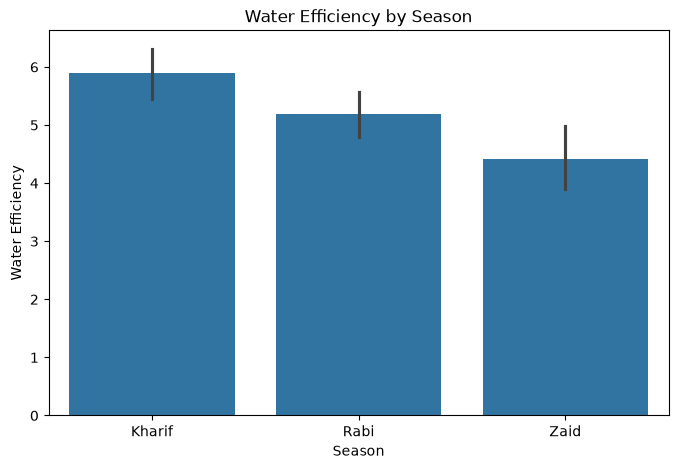

In [19]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=df,
    x="Season",
    y="Water_Efficiency_t_per_1000m3",
    estimator="mean"
)

plt.title("Water Efficiency by Season")
plt.xlabel("Season")
plt.ylabel("Water Efficiency")
plt.show()

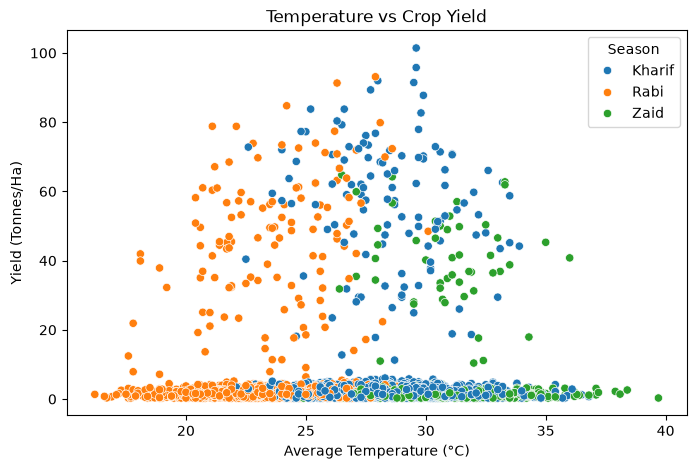

In [20]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x="Avg_Temperature_C",
    y="Yield_Tonnes_Ha",
    hue="Season"
)

plt.title("Temperature vs Crop Yield")
plt.xlabel("Average Temperature (°C)")
plt.ylabel("Yield (Tonnes/Ha)")
plt.show()

In [21]:
water_summary = df.groupby("Season")[
    ["Water_Used_m3", "Water_Efficiency_t_per_1000m3"]
].mean()

water_summary

,Water_Used_m3,Water_Efficiency_t_per_1000m3
Season,,
Kharif,6102.201237,5.891834
Rabi,5846.987093,5.186122
Zaid,6419.893939,4.413239


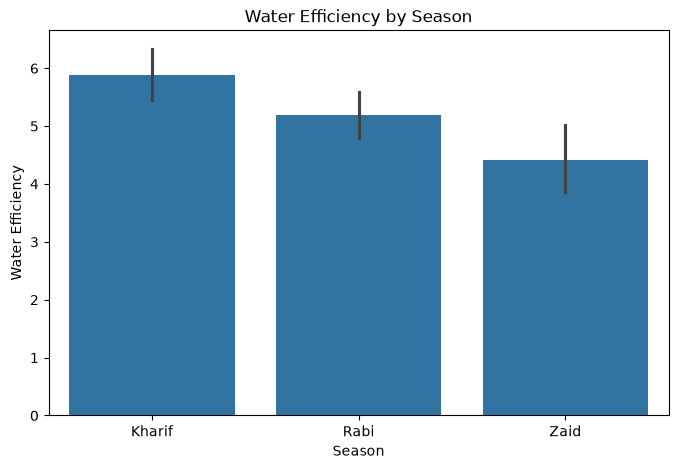

In [22]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=df,
    x="Season",
    y="Water_Efficiency_t_per_1000m3",
    estimator="mean"
)

plt.title("Water Efficiency by Season")
plt.xlabel("Season")
plt.ylabel("Water Efficiency")
plt.show()

In [24]:
numeric_columns = [
    "Rainfall_mm",
    "Avg_Temperature_C",
    "Humidity_pct",
    "Sunlight_Hours_Day",
    "Soil_pH",
    "Soil_Moisture_pct",
    "Nitrogen_kg_ha",
    "Phosphorus_kg_ha",
    "Potassium_kg_ha",
    "Fertilizer_kg_ha",
    "Pesticide_Litre_ha",
    "Seed_Quality_Score",
    "Yield_Tonnes_Ha",
    "Production_Tonnes",
    "Market_Price_INR_Tonne",
    "Total_Cost_INR",
    "Revenue_INR",
    "Profit_INR",
    "Water_Used_m3",
    "Water_Efficiency_t_per_1000m3",
    "Disease_Pest_Risk_pct"
]

correlation = df[numeric_columns].corr()

correlation["Yield_Tonnes_Ha"].sort_values(ascending=False)

Yield_Tonnes_Ha                  1.000000
Water_Efficiency_t_per_1000m3    0.915438
Production_Tonnes                0.885171
Profit_INR                       0.489822
Revenue_INR                      0.433648
Water_Used_m3                    0.388653
Nitrogen_kg_ha                   0.053867
Phosphorus_kg_ha                 0.047821
Rainfall_mm                      0.030853
Total_Cost_INR                   0.030814
Disease_Pest_Risk_pct            0.013490
Humidity_pct                     0.011277
Soil_Moisture_pct                0.010210
Avg_Temperature_C                0.009349
Potassium_kg_ha                  0.003836
Fertilizer_kg_ha                 0.000562
Seed_Quality_Score              -0.006737
Pesticide_Litre_ha              -0.007650
Sunlight_Hours_Day              -0.015362
Soil_pH                         -0.020664
Market_Price_INR_Tonne          -0.384307
Name: Yield_Tonnes_Ha, dtype: float64

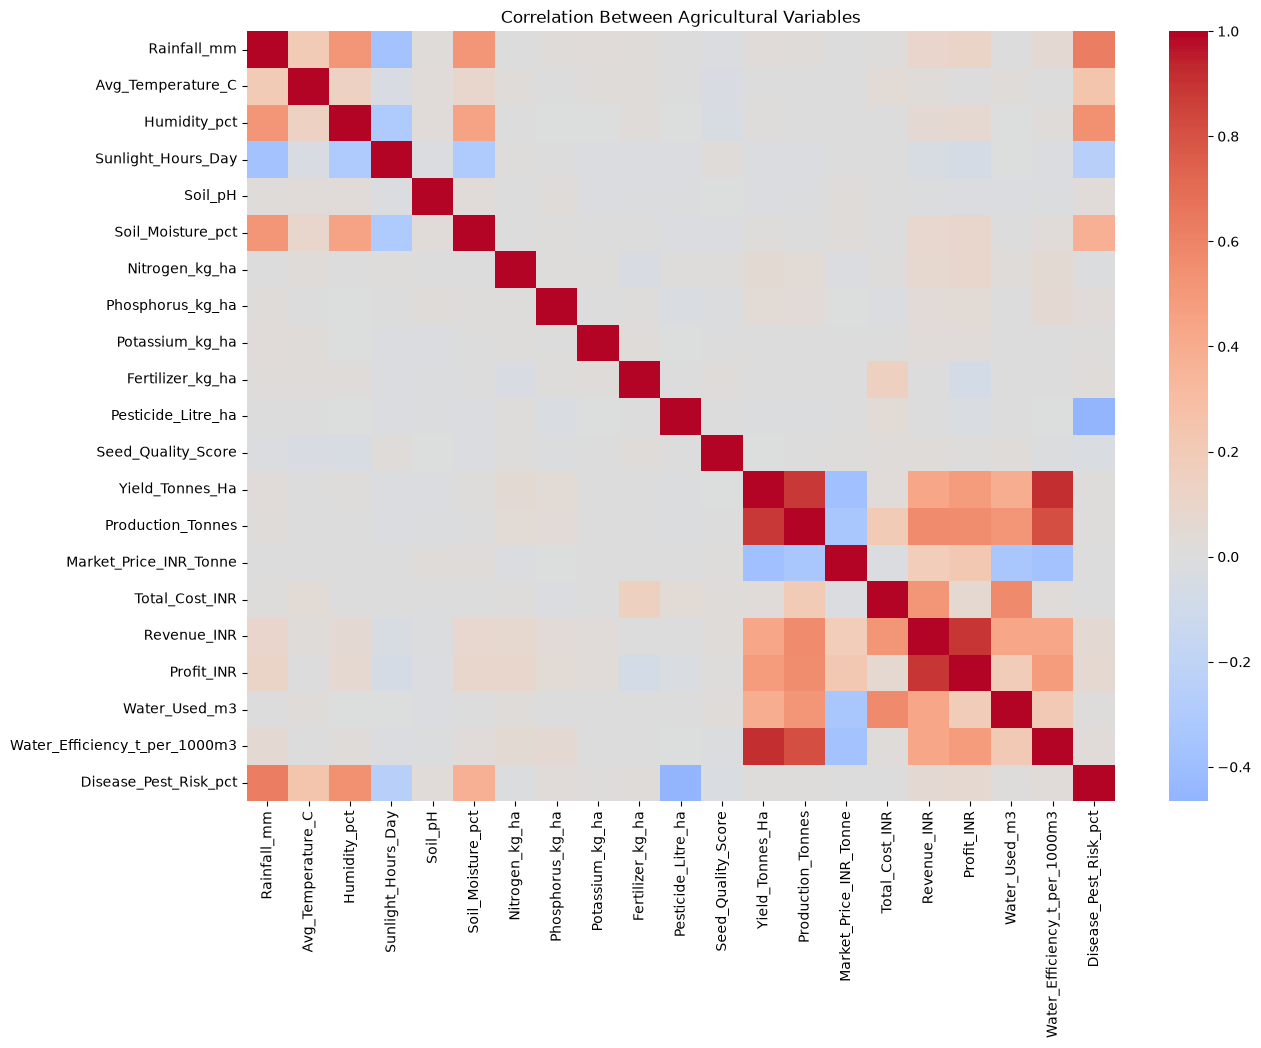

In [23]:
plt.figure(figsize=(14,10))

sns.heatmap(
    correlation,
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Between Agricultural Variables")
plt.show()

In [25]:
final_summary = df.groupby("Season").agg({
    "Yield_Tonnes_Ha": "mean",
    "Production_Tonnes": "mean",
    "Revenue_INR": "mean",
    "Profit_INR": "mean",
    "Water_Used_m3": "mean",
    "Water_Efficiency_t_per_1000m3": "mean",
    "Disease_Pest_Risk_pct": "mean"
}).round(2)

final_summary

,Yield_Tonnes_Ha,Production_Tonnes,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
Season,,,,,,,
Kharif,5.64,46.31,710719.06,178914.65,6102.20,5.89,54.47
Rabi,5.08,41.49,601526.05,87689.47,5846.99,5.19,40.48
Zaid,4.67,38.89,519171.90,-24804.82,6419.89,4.41,38.22
